# Restaurant Review Sentiment Analysis using NLP

## Project Overview

This project analyzes restaurant customer reviews and builds a machine learning model to classify reviews as positive or negative.

The main goal is to understand customer sentiment from review text and create a simple sentiment prediction system that can be used in a Streamlit web application.

## Objectives

- Load and explore restaurant review data
- Clean rating and review text columns
- Create sentiment labels using customer ratings
- Preprocess text data for NLP
- Convert text into numerical features using TF-IDF
- Train a sentiment classification model
- Evaluate model performance
- Save the trained model for Streamlit deployment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1. Loading the Dataset

The dataset contains restaurant reviews along with customer ratings and other metadata.  
For this sentiment analysis project, the most important columns are:

- `Review`: customer review text
- `Rating`: numerical rating given by the customer

In [2]:
df = pd.read_csv("../data/Restaurant reviews.csv")

df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,2447.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,NaN
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,NaN
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,NaN
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,NaN


In [3]:
print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns)

Dataset shape: (10000, 8)
Columns:
Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures', '7514'],
      dtype='str')


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Restaurant  10000 non-null  str    
 1   Reviewer    9962 non-null   str    
 2   Review      9955 non-null   str    
 3   Rating      9962 non-null   str    
 4   Metadata    9962 non-null   str    
 5   Time        9962 non-null   str    
 6   Pictures    10000 non-null  int64  
 7   7514        1 non-null      float64
dtypes: float64(1), int64(1), str(6)
memory usage: 3.9 MB


In [5]:
df.isnull().sum()

Restaurant       0
Reviewer        38
Review          45
Rating          38
Metadata        38
Time            38
Pictures         0
7514          9999
dtype: int64

## 2. Selecting Relevant Columns

For this project, only the review text and rating are required.

The `Review` column will be used as the input feature, and the `Rating` column will be used to create sentiment labels.

In [6]:
df = df[["Review", "Rating"]]

df.head()

,Review,Rating
0,"The ambience was good, food was quite good . h...",5
1,Ambience is too good for a pleasant evening. S...,5
2,A must try.. great food great ambience. Thnx f...,5
3,Soumen das and Arun was a great guy. Only beca...,5
4,Food is good.we ordered Kodi drumsticks and ba...,5


In [7]:
df.isnull().sum()

Review    45
Rating    38
dtype: int64

In [8]:
df = df.dropna(subset=["Review", "Rating"])

df.isnull().sum()

Review    0
Rating    0
dtype: int64

## 3. Cleaning the Rating Column

The rating column contains numerical values, but some values may be stored as text or contain invalid entries.

To prepare the data for sentiment labeling, the rating column is converted into numeric format. Invalid values are converted into missing values and removed.

In [9]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df = df.dropna(subset=["Rating"])

df["Rating"].value_counts().sort_index()

Rating
1.0    1735
1.5       9
2.0     684
2.5      19
3.0    1192
3.5      47
4.0    2373
4.5      69
5.0    3826
Name: count, dtype: int64

## 4. Creating Sentiment Labels

The original dataset does not directly contain sentiment labels such as Positive or Negative.

Therefore, sentiment labels are created using the rating column:

- Ratings greater than or equal to 4 are labeled as `Positive`
- Ratings less than or equal to 2 are labeled as `Negative`
- Neutral ratings such as 3 and 3.5 are removed to build a clear binary classification model

In [10]:
df = df[(df["Rating"] >= 4) | (df["Rating"] <= 2)]

df["Sentiment"] = df["Rating"].apply(lambda rating: "Positive" if rating >= 4 else "Negative")

df.head()

,Review,Rating,Sentiment
0,"The ambience was good, food was quite good . h...",5.0,Positive
1,Ambience is too good for a pleasant evening. S...,5.0,Positive
2,A must try.. great food great ambience. Thnx f...,5.0,Positive
3,Soumen das and Arun was a great guy. Only beca...,5.0,Positive
4,Food is good.we ordered Kodi drumsticks and ba...,5.0,Positive


In [11]:
df["Sentiment"].value_counts()

Sentiment
Positive    6268
Negative    2428
Name: count, dtype: int64

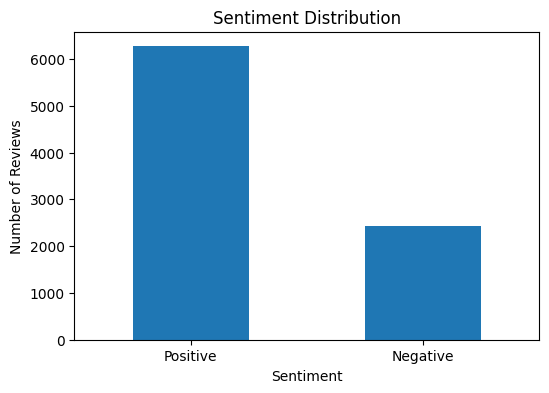

In [12]:
# Visualize the distribution of sentiments
plt.figure(figsize=(6, 4))
df["Sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

## 5. Text Preprocessing

Text preprocessing is an important step in NLP.

The review text is cleaned by:

- Converting text to lowercase
- Removing numbers and special characters
- Removing extra spaces

This helps the machine learning model focus on meaningful words in the reviews.

In [13]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [14]:
df["Cleaned_Review"] = df["Review"].apply(clean_text)

df[["Review", "Cleaned_Review", "Sentiment"]].head()

,Review,Cleaned_Review,Sentiment
0,"The ambience was good, food was quite good . h...",the ambience was good food was quite good had ...,Positive
1,Ambience is too good for a pleasant evening. S...,ambience is too good for a pleasant evening se...,Positive
2,A must try.. great food great ambience. Thnx f...,a must try great food great ambience thnx for ...,Positive
3,Soumen das and Arun was a great guy. Only beca...,soumen das and arun was a great guy only becau...,Positive
4,Food is good.we ordered Kodi drumsticks and ba...,food is goodwe ordered kodi drumsticks and bas...,Positive


In [15]:
df[df["Cleaned_Review"] == ""].shape

(14, 4)

In [16]:
df = df[df["Cleaned_Review"] != ""]

df.shape

(8682, 4)